# LINC for Causal Discovery from Multi-Context Tabular Data

Demo of LINC.





In [8]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from causalchange import Linc
from causalchange.plotting import plot_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Synthetic nonlinear data



In [2]:
true_edges = {
    ("x0", "x1"),
    ("x0", "x2"),
    ("x1", "x3"),
    ("x2", "x3"),
    ("x3", "x4"),
}


def standardize(df: pd.DataFrame) -> pd.DataFrame:
    return (df - df.mean(axis=0)) / df.std(axis=0)


def simulate_linc_contexts(
    n_per_context: int = 400,
    contexts: tuple[str, ...] = ("A", "B", "C"),
    seed: int = 42,
    noise_scale: float = 0.30,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = []

    for context_idx, context in enumerate(contexts):
        n = n_per_context

        x0 = rng.normal(size=n)

        # Same graph, slightly changed mechanisms.
        a1 = 1.2 + 0.15 * context_idx
        a2 = 0.6 - 0.10 * context_idx
        a3 = 0.7 + 0.10 * context_idx

        x1 = np.tanh(a1 * x0) + rng.normal(scale=noise_scale, size=n)
        x2 = a2 * x0**2 + 0.3 * x0 + rng.normal(scale=noise_scale, size=n)
        x3 = np.sin(x1) + a3 * x2 + rng.normal(scale=noise_scale, size=n)
        x4 = np.tanh(x3) + rng.normal(scale=noise_scale, size=n)

        frame = pd.DataFrame(
            {
                "context": context,
                "x0": x0,
                "x1": x1,
                "x2": x2,
                "x3": x3,
                "x4": x4,
            }
        )

        value_cols = [c for c in frame.columns if c != "context"]
        frame[value_cols] = standardize(frame[value_cols])
        frames.append(frame)

    return pd.concat(frames, axis=0, ignore_index=True)


X_contexts = simulate_linc_contexts()
X_contexts.head()

,context,x0,x1,x2,x3,x4
0,A,0.325411,0.445621,-0.717163,-0.503482,-0.462573
1,A,-1.086579,-1.066140,-0.585700,-1.156013,-0.699986
2,A,0.793450,1.374162,0.142198,1.052761,1.763424
3,A,0.993077,0.997576,0.431681,0.899452,0.477819
4,A,-2.043219,-1.117170,1.719438,0.189044,0.428621


## 2. LINC

In [9]:
cc_linc = Linc(context_col="context")
cc_linc.fit(X_contexts)

print("Topological order:")
print(cc_linc.topological_order_)

print("\nLINC edges:")
for edge in sorted(cc_linc.graph_.edges()):
    print("  ", edge)

print("\nEdge strengths:")
pd.Series(cc_linc.result_.edge_strengths, name="strength").sort_values(ascending=False)

Topological order:
['x0', 'x1', 'x2', 'x3', 'x4']

LINC edges:
   ('x0', 'x1')
   ('x0', 'x2')
   ('x1', 'x3')
   ('x2', 'x3')
   ('x3', 'x4')

Edge strengths:


Series([], Name: strength, dtype: object)

In [10]:
def edge_recovery_summary(estimated_edges, true_edges):
    estimated_edges = set(estimated_edges)
    true_edges = set(true_edges)

    tp = estimated_edges & true_edges
    fp = estimated_edges - true_edges
    fn = true_edges - estimated_edges

    precision = len(tp) / max(len(tp) + len(fp), 1)
    recall = len(tp) / max(len(tp) + len(fn), 1)

    return {
        "precision": precision,
        "recall": recall,
        "true_positives": sorted(tp),
        "false_positives": sorted(fp),
        "false_negatives": sorted(fn),
    }


edge_recovery_summary(cc_linc.graph_.edges(), true_edges)

{'precision': 1.0,
 'recall': 1.0,
 'true_positives': [('x0', 'x1'),
  ('x0', 'x2'),
  ('x1', 'x3'),
  ('x2', 'x3'),
  ('x3', 'x4')],
 'false_positives': [],
 'false_negatives': []}

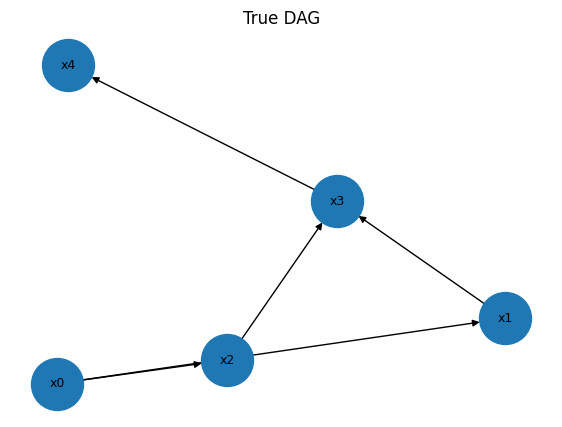

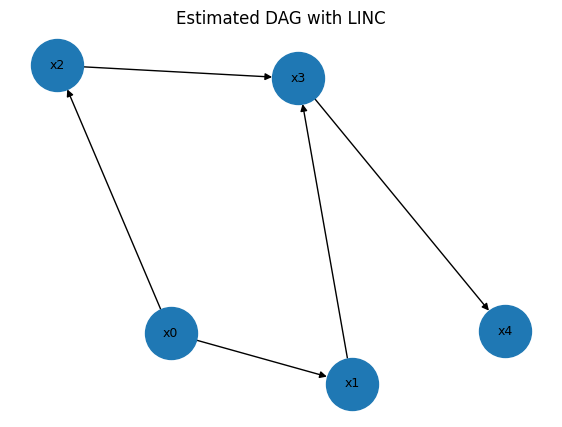

In [11]:
true_graph = nx.DiGraph()
true_graph.add_edges_from(true_edges)

plot_graph(true_graph, title="True DAG")
plt.show()

plot_graph(cc_linc.graph_, title="Estimated DAG with LINC")
plt.show()